In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv('../data/credit_risk.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.shape

(32581, 12)

In [5]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [7]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [8]:
df["person_emp_length"] = df["person_emp_length"].fillna(
    df["person_emp_length"].median()
)

df["loan_int_rate"] = df["loan_int_rate"].fillna(
    df["loan_int_rate"].median()
    )
print("Missing values handled successfully!")

Missing values handled successfully!


In [9]:
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [10]:
df["person_home_ownership"] = df["person_home_ownership"].map({
    "RENT": 0,
    "OWN": 1,
    "MORTGAGE": 2,
    "OTHER": 3
})

df["loan_intent"] = df["loan_intent"].map({
    "PERSONAL": 0,
    "EDUCATION": 1,
    "MEDICAL": 2,
    "VENTURE": 3,
    "HOMEIMPROVEMENT": 4,
    "DEBTCONSOLIDATION": 5
})

df["loan_grade"] = df["loan_grade"].map({
    "A": 0,
    "B": 1,
    "C": 2,
    "D": 3,
    "E": 4,
    "F": 5,
    "G": 6
})

df["cb_person_default_on_file"] = df["cb_person_default_on_file"].map({
    "N": 0,
    "Y": 1
})

print("Categorical data encoded successfully!")

Categorical data encoded successfully!


In [11]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,0,123.0,0,3,35000,16.02,1,0.59,1,3
1,21,9600,1,5.0,1,1,1000,11.14,0,0.10,0,2
2,25,9600,2,1.0,2,2,5500,12.87,1,0.57,0,3
3,23,65500,0,4.0,2,2,35000,15.23,1,0.53,0,2
4,24,54400,0,8.0,2,2,35000,14.27,1,0.55,1,4


In [12]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (32581, 11)
y shape: (32581,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (26064, 11)
Testing data: (6517, 11)


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [15]:
from sklearn.linear_model import LogisticRegression

credit_model = LogisticRegression(max_iter=5000)

credit_model.fit(X_train_scaled, y_train)

print("Credit Risk Logistic Regression model trained successfully!")

Credit Risk Logistic Regression model trained successfully!


In [16]:
y_pred = credit_model.predict(X_test_scaled)

print("Credit Risk Prediction completed successfully!")
print(y_pred[:20])

Credit Risk Prediction completed successfully!
[0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0]


In [17]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Credit Risk Model Accuracy:", accuracy)
print("Accuracy Percentage:", round(accuracy * 100, 2), "%")

Credit Risk Model Accuracy: 0.8490102808040509
Accuracy Percentage: 84.9 %


In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.95      0.91      5095
           1       0.74      0.48      0.58      1422

    accuracy                           0.85      6517
   macro avg       0.80      0.72      0.74      6517
weighted avg       0.84      0.85      0.84      6517



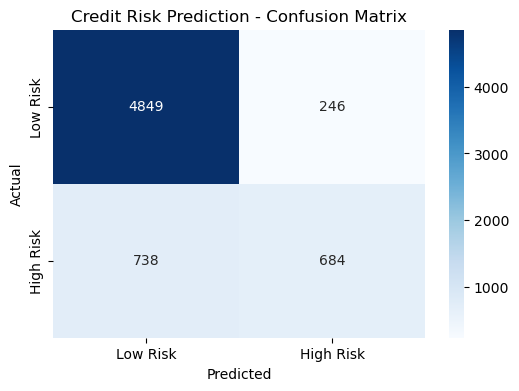

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Risk", "High Risk"],
    yticklabels=["Low Risk", "High Risk"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Credit Risk Prediction - Confusion Matrix")
plt.show()

In [20]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(credit_model, "../models/credit_risk_model.pkl")
joblib.dump(scaler, "../models/credit_risk_scaler.pkl")

print("Credit Risk model and scaler saved successfully!")

Credit Risk model and scaler saved successfully!


loan_status
0    25473
1     7108
Name: count, dtype: int64


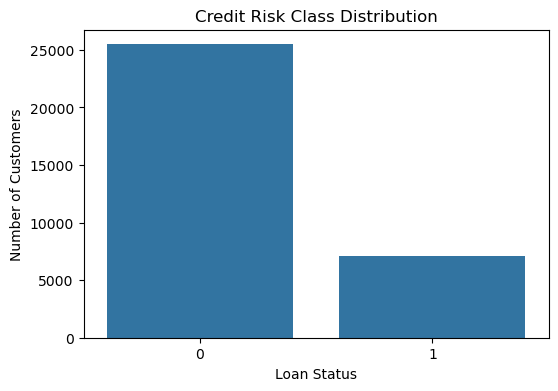

In [21]:
print(df["loan_status"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x="loan_status", data=df)

plt.title("Credit Risk Class Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Customers")
plt.show()

In [22]:
from sklearn.linear_model import LogisticRegression

balanced_model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced"
)

balanced_model.fit(X_train_scaled, y_train)

print("Balanced Credit Risk model trained successfully!")

Balanced Credit Risk model trained successfully!


In [23]:
y_pred_balanced = balanced_model.predict(X_test_scaled)

print("Balanced model prediction completed successfully!")
print(y_pred_balanced[:20])

Balanced model prediction completed successfully!
[0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 1 0]


In [24]:
from sklearn.metrics import accuracy_score, classification_report

balanced_accuracy = accuracy_score(y_test, y_pred_balanced)

print("Balanced Model Accuracy:", balanced_accuracy)
print("Accuracy Percentage:", round(balanced_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))

Balanced Model Accuracy: 0.7870185668252263
Accuracy Percentage: 78.7 %

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.79      0.85      5095
           1       0.51      0.77      0.61      1422

    accuracy                           0.79      6517
   macro avg       0.72      0.78      0.73      6517
weighted avg       0.83      0.79      0.80      6517



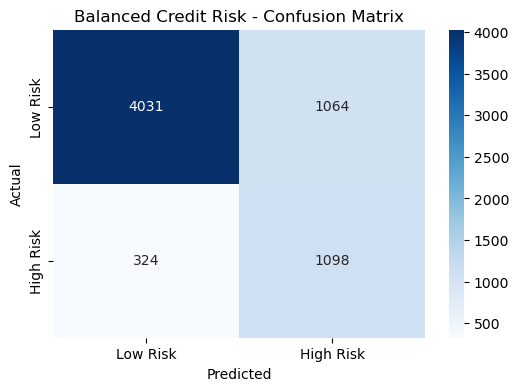

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_balanced = confusion_matrix(y_test, y_pred_balanced)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_balanced,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Risk", "High Risk"],
    yticklabels=["Low Risk", "High Risk"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Balanced Credit Risk - Confusion Matrix")
plt.show()

In [26]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(balanced_model, "../models/credit_risk_balanced_model.pkl")
joblib.dump(scaler, "../models/credit_risk_balanced_scaler.pkl")

print("Balanced Credit Risk model and scaler saved successfully!")

Balanced Credit Risk model and scaler saved successfully!


In [27]:
print("====================================")
print("   CREDIT RISK PREDICTION MODEL")
print("====================================")
print("Algorithm: Logistic Regression")
print("Model Type: Balanced")
print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])
print("Number of Features:", X_train.shape[1])
print("Accuracy:", round(balanced_accuracy * 100, 2), "%")
print("High Risk Recall:", 77, "%")

   CREDIT RISK PREDICTION MODEL
Algorithm: Logistic Regression
Model Type: Balanced
Training Samples: 26064
Testing Samples: 6517
Number of Features: 11
Accuracy: 78.7 %
High Risk Recall: 77 %
